In [15]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

In [16]:
from pathlib import Path
import h5py

diagnostics_path = Path("data/test_bursting_diagnostics_0.25.h5")

if not diagnostics_path.exists():
    raise FileNotFoundError("Run `python run_test_diagnostics.py` first to generate diagnostics data.")

with h5py.File(diagnostics_path, "r") as f:
    completed_step = int(f.attrs.get("completed_step", len(f["time/t"]) - 1))
    data_slice = slice(0, completed_step + 1)
    error_slice = slice(0, completed_step)
    
    t = f["time/t"][data_slice]
    
    gamma_data = {key: f[f"gamma_1000/{key}"][data_slice] for key in f["gamma_1000"]}
    gamma0_data = {key: f[f"gamma_0/{key}"][data_slice] for key in f["gamma_0"]}
    ref_data = {key: f[f"etdrk4_ref/{key}"][data_slice] for key in f["etdrk4_ref"]}
    
    l2_error_gamma = f["errors/l2_error_gamma_1000"][error_slice]
    l2_error_gamma0 = f["errors/l2_error_gamma_0"][error_slice]
    rel_l2_gamma = f["errors/rel_l2_gamma_1000"][error_slice]
    rel_l2_gamma0 = f["errors/rel_l2_gamma_0"][error_slice]

enstrophy_gamma = gamma_data["Enstrophy"]
enstrophy_gamma0 = gamma0_data["Enstrophy"]
enstrophy_ref = ref_data["Enstrophy"]

q_gamma = gamma_data["q"]
q_gamma0 = gamma0_data["q"]
q_dev_gamma = np.abs(q_gamma - 1.0)
q_dev_gamma0 = np.abs(q_gamma0 - 1.0)

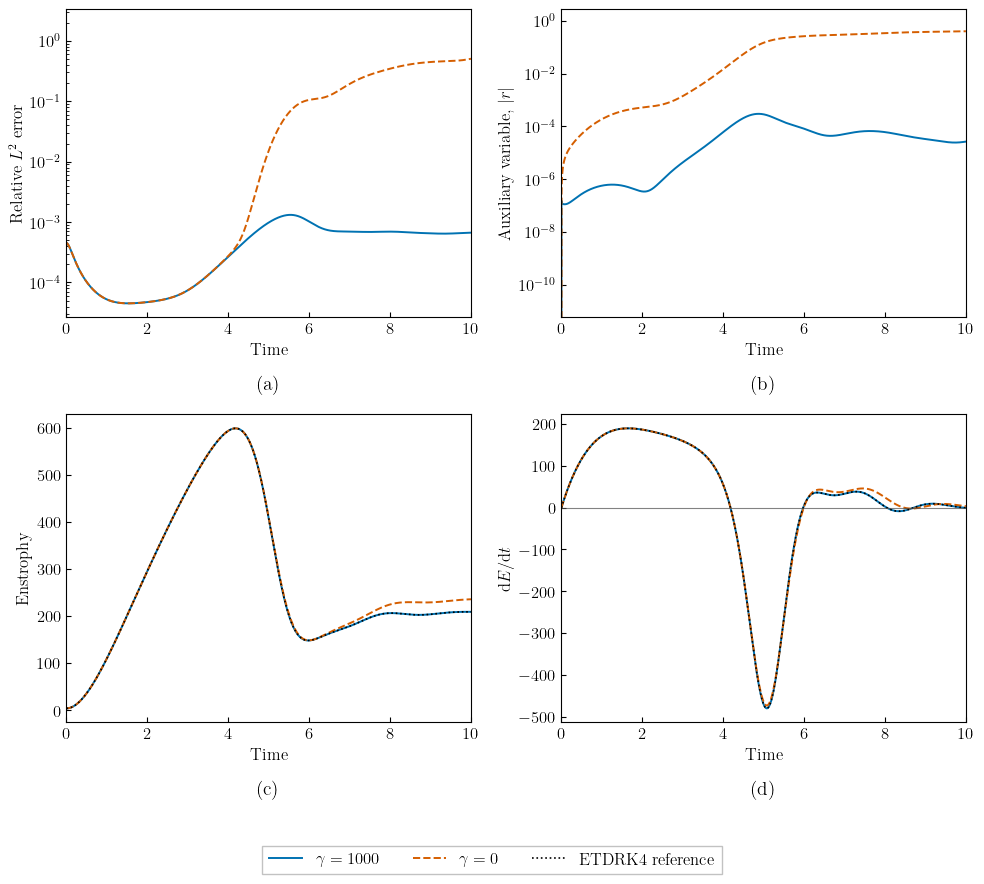

In [27]:
from pathlib import Path
import matplotlib as mpl
from matplotlib.ticker import LogLocator

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Publication-ready styling: vector-friendly fonts, compact journal width,
# colorblind-safe colors, and redundant line/marker encodings.
okabe_ito = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "black": "#000000",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 9), dpi=100)
ax0, ax1 = axes[0]
ax2, ax3 = axes[1]

# A: relative L2 error against ETDRK4
ax0.semilogy(t[1:], rel_l2_gamma, color=okabe_ito["blue"], lw=1.4,
             label=r"$\gamma=1000$")
ax0.semilogy(t[1:], rel_l2_gamma0, color=okabe_ito["orange"], lw=1.4,
             ls="--", label=r"$\gamma=0$")
ax0.set_xlabel(r"Time")
ax0.set_ylabel(r"Relative $L^2$ error")
ax0.set_xlim(left=0, right=10)
ax0.yaxis.set_major_locator(LogLocator(base=10))

# B: auxiliary-variable deviation
ax1.semilogy(t[1:], q_dev_gamma[1:], color=okabe_ito["blue"], lw=1.4, label=r"$\gamma=1000$")
ax1.semilogy(t[1:], q_dev_gamma0[1:], color=okabe_ito["orange"], lw=1.4, ls="--", label=r"$\gamma=0$")
ax1.set_xlabel(r"Time")
ax1.set_ylabel(r"Auxiliary variable, $|r|$")
ax1.yaxis.set_major_locator(LogLocator(base=10))
ax1.set_xlim(left=0, right=10)

# C: enstrophy evolution
ax2.plot(t[1:], enstrophy_gamma[1:], color=okabe_ito["blue"], lw=1.4, label=r"$\gamma=1000$")
ax2.plot(t[1:], enstrophy_gamma0[1:], color=okabe_ito["orange"], lw=1.4, ls="--", label=r"$\gamma=0$")
ax2.plot(t[1:], enstrophy_ref[1:], color=okabe_ito["black"], lw=1.2, ls=":", label="ETDRK4 reference")
ax2.set_xlabel(r"Time")
ax2.set_ylabel(r"Enstrophy")
ax2.set_xlim(left=0, right=10)

# D: enstrophy rate of change

def enstrophy_rate(time, enstrophy):
    time = np.asarray(time)
    enstrophy = np.asarray(enstrophy)
    return 0.5 * (time[1:] + time[:-1]), np.diff(enstrophy) / np.diff(time)


t_rate_gamma, enstrophy_rate_gamma = enstrophy_rate(t, enstrophy_gamma)
t_rate_gamma0, enstrophy_rate_gamma0 = enstrophy_rate(t, enstrophy_gamma0)
t_rate_ref, enstrophy_rate_ref = enstrophy_rate(t, enstrophy_ref)

ax3.plot(t_rate_gamma, enstrophy_rate_gamma, color=okabe_ito["blue"], lw=1.4,
         label=r"$\gamma=1000$")
ax3.plot(t_rate_gamma0, enstrophy_rate_gamma0, color=okabe_ito["orange"], lw=1.4,
         ls="--", label=r"$\gamma=0$")
ax3.plot(t_rate_ref, enstrophy_rate_ref, color=okabe_ito["black"], lw=1.2,
         ls=":", label="ETDRK4 reference")
ax3.axhline(0.0, color="0.3", lw=0.8, alpha=0.7)
ax3.set_xlabel(r"Time")
ax3.set_ylabel(r"$\mathrm{d}E/\mathrm{d}t$")
ax3.set_xlim(left=0, right=10)

for label, ax in zip(["(a)", "(b)", "(c)", "(d)"], [ax0, ax1, ax2, ax3]):
    ax.text(0.5, -0.22, label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", ha="center", va="center")

handles, labels = [], []
for ax in [ax0, ax1, ax2, ax3]:
    ax_handles, ax_labels = ax.get_legend_handles_labels()
    for handle, label in zip(ax_handles, ax_labels):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, 0.01), framealpha=0.95,
           edgecolor="0.75", fancybox=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("./fig/mrSAV_comparison_publication.pdf")
# fig.savefig("./fig/mrSAV_comparison_publication.png", dpi=600)
plt.show()
